# 3.3. Schrödinger 방정식

In [1]:
import sympy as sp

x, t = sp.symbols("x t")
k, w, m, hbar = sp.symbols("k omega m hbar", positive=True)

psi = sp.exp(sp.I * (k * x - w * t))

left = sp.I * hbar * sp.diff(psi, t)
right = -(hbar**2) / (2 * m) * sp.diff(psi, x, 2)

print("좌변 / psi =", sp.simplify(left / psi))
print("우변 / psi =", sp.simplify(right / psi))

좌변 / psi = hbar*omega
우변 / psi = hbar**2*k**2/(2*m)


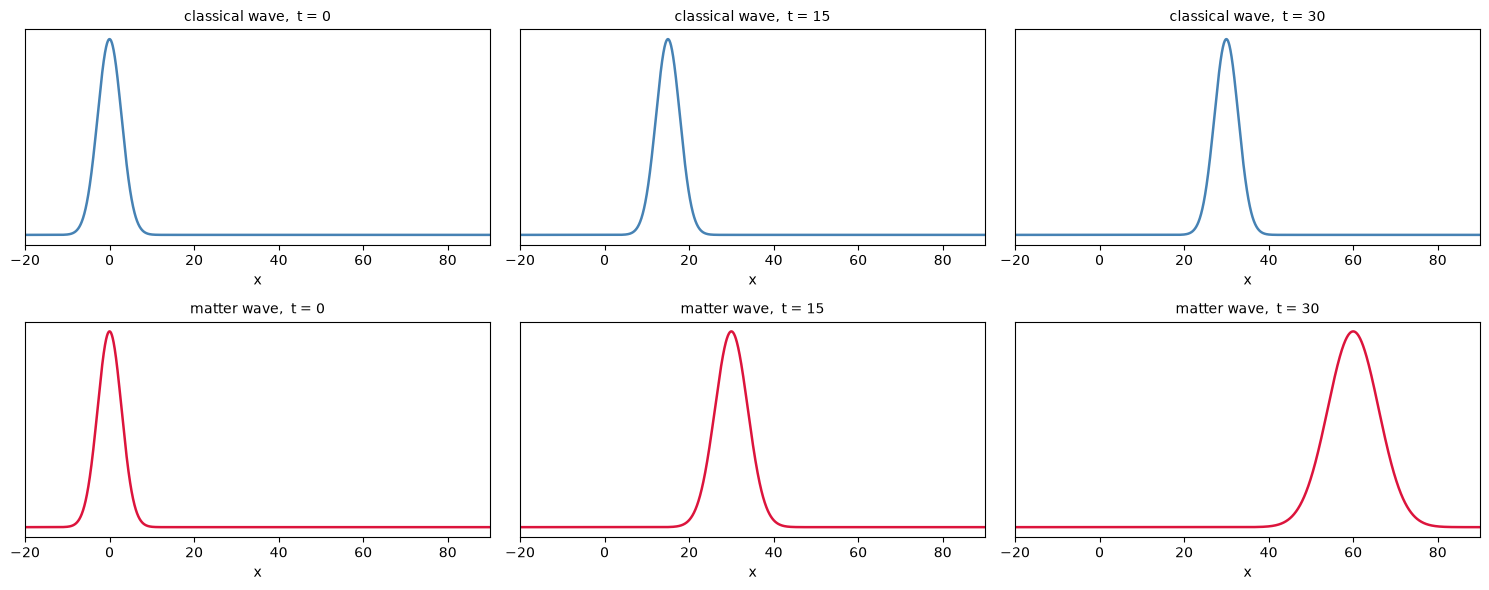

In [6]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-40, 90, 3000)
k0, sk = 2.0, 0.25
k = np.linspace(k0 - 6 * sk, k0 + 6 * sk, 1200)
A = np.exp(-((k - k0) ** 2) / (2 * sk**2))


def packet(t, dispersion):
    w = dispersion(k)
    return (A[:, None] * np.exp(1j * (k[:, None] * x[None, :] - w[:, None] * t))).sum(
        axis=0
    )


classical = lambda kk: 1.0 * kk  # omega = v k
quantum = lambda kk: 0.5 * kk**2  # omega = hbar k^2 / 2m  (hbar = m = 1)

fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharey="row")

for j, t in enumerate([0, 15, 30]):
    for i, (disp, name, col) in enumerate(
        [
            (classical, "classical wave", "steelblue"),
            (quantum, "matter wave", "crimson"),
        ]
    ):
        p = np.abs(packet(t, disp)) ** 2
        axes[i, j].plot(x, p / p.max(), color=col, lw=1.8)
        axes[i, j].set_xlim(-20, 90)
        axes[i, j].set_yticks([])
        axes[i, j].set_title(f"{name},  t = {t}", fontsize=10)
        axes[i, j].set_xlabel("x")

plt.tight_layout()
plt.show()

In [5]:
def width(t, disp):
    p = np.abs(packet(t, disp)) ** 2
    p = p / np.trapezoid(p, x)
    mu = np.trapezoid(x * p, x)
    return np.sqrt(np.trapezoid((x - mu) ** 2 * p, x))


print(f"{'t':>4}  {'고전파 폭':>10}  {'물질파 폭':>10}")
for t in [0, 10, 20, 30]:
    print(f"{t:4d}  {width(t, classical):10.3f}  {width(t, quantum):10.3f}")

   t       고전파 폭       물질파 폭
   0       2.828       2.828
  10       2.828       3.335
  20       2.828       4.528
  30       2.828       6.010
